In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Feature names:", iris.feature_names)

Shape of X: (150, 4)
Shape of y: (150,)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


Task 1.1
- 150 observations.
- 4 features.
- The target variable should not be used because unsupervised learning is intended to discover natural structure in the data without predefined labels. Using the target would give the algorithm information about the known groups and would therefore undermine the purpose of the clustering experiment.
- The problem would become a supervised learning problem, because the model would be learning from known target labels rather than discovering groups on its own.

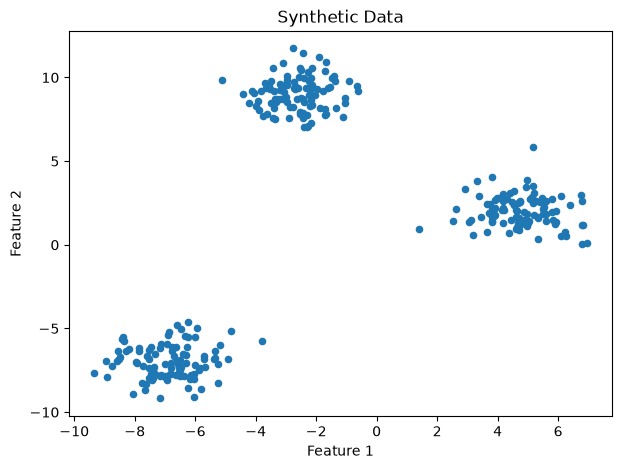

In [3]:
from sklearn.datasets import make_blobs
X_blobs, y_blobs = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.0,
    random_state=42
)  
plt.figure(figsize=(7,5))

plt.scatter(
    X_blobs[:, 0],
    X_blobs[:, 1],
    s=20
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic Data")
plt.show()

Task 2.1
- Approximately 3 groups.
- Points within the same group are close together, while points belonging to different groups are farther apart.
- The synthetic dataset has only two features, allowing us to plot every observation directly on a 2D graph. Iris has four features, making direct visualization of all dimensions more difficult.
- cluster_std controls the spread of observations around the cluster centers.

In [5]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)
kmeans.fit(X_blobs)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 2)","[[-2.

In [6]:
print("Cluster centers:")
print(kmeans.cluster_centers_)

Cluster centers:
[[-2.63323268  9.04356978]
 [-6.88387179 -6.98398415]
 [ 4.74710337  2.01059427]]


In [7]:
cluster_labels = kmeans.predict(X_blobs)

print ( cluster_labels [:20])

[1 1 0 2 1 2 0 2 0 0 0 2 0 0 1 0 1 2 0 0]


In [8]:
cluster_labels = kmeans.labels_

Task 3.1
- They represent the cluster identifiers assigned by K-Means to each observation.
- No, they are simply labels used to identify the clusters.
- Cluster number 0 can not be automatically be interpretted as first class Because K-Means is discovering clusters, not learning predefined classes.
- cluster_centers_ contains the coordinates of the centroids learned by K-Means.

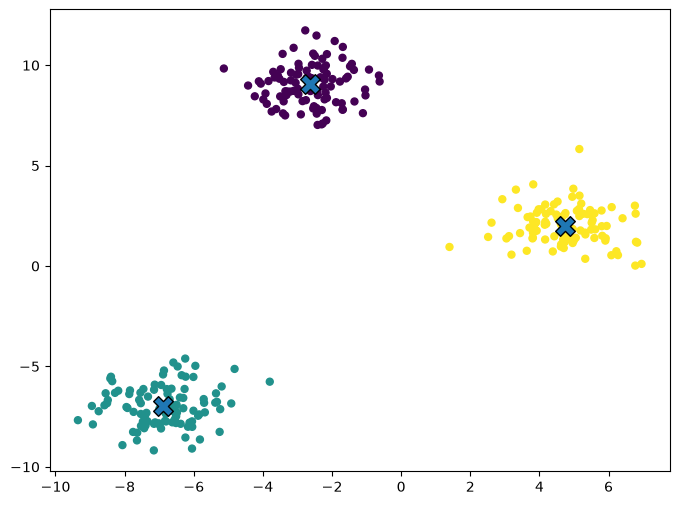

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_blobs[:, 0],
    X_blobs[:, 1],
    c=cluster_labels,
    s=25
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200,
    edgecolor="black"
)

Task 4.1
- They are located at the centroids learned by K-Means, shown as large X markers on the plot.
- Each observation is assigned to the cluster whose centroid is closest to that observation.
- No. Some observations are close to their centroid, while others are farther away.
- Yes. Observations located between groups can be relatively close to more than one centroid and therefore appear near the decision boundaries.

In [10]:
x_min, x_max = X_blobs[:, 0].min() - 1, X_blobs[:, 0].max() + 1

y_min, y_max = X_blobs[:, 1].min() - 1, X_blobs[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = kmeans.predict(grid)
Z = Z.reshape(xx.shape)

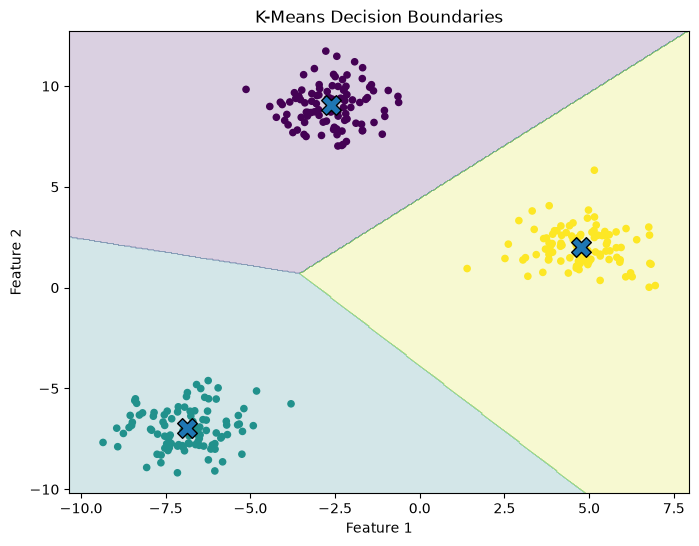

In [12]:
plt.figure(figsize=(8, 6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.2
)

plt.scatter(
    X_blobs[:, 0],
    X_blobs[:, 1],
    c=cluster_labels,
    s=20
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200,
    edgecolor="black"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Decision Boundaries")
plt.show()

Task 4.2
- Each region represents an area of the feature space where observations would be assigned to the same cluster because they are closest to the same centroid.
- The boundaries separate regions according to which cluster centroid is closest. Therefore, the position of the centroids determines the location of the boundaries.
- K-Means assigns each observation to the nearest centroid.
- The boundaries can also move because the nearest-centroid relationships change.

In [13]:
print("Inertia :", kmeans.inertia_)

Inertia : 566.8595511244132


Task 5.1
- Inertia measures the sum of the squared distances between observations and the centroids of their assigned clusters.
- Yes. A smaller inertia generally indicates that observations are closer to their assigned centroids and therefore the clusters are more compact.
- Because inertia generally decreases as the number of clusters increases. Therefore, the lowest inertia does not necessarily represent the most appropriate or meaningful number of clusters.
- 

In [14]:
for seed in [0, 1, 2, 3, 4]:

    model = KMeans(
        n_clusters=3,
        random_state=seed,
        n_init=1
    )

    model.fit(X_blobs)

    print(
        "Random state :", seed,
        "Inertia :", model.inertia_
    )

Random state : 0 Inertia : 566.8595511244132
Random state : 1 Inertia : 566.8595511244132
Random state : 2 Inertia : 566.8595511244132
Random state : 3 Inertia : 566.8595511244132
Random state : 4 Inertia : 566.8595511244132


Task 6.1
- Yes, all five random states produced the same inertia value:
566.8595511244132
- K-Means starts with initial cluster centers. Different initial positions can sometimes lead to different final clustering solutions and therefore different inertia values.
- The solution with the lower inertia would generally be preferred because it represents a solution with smaller squared distances between observations and their assigned cluster centers.
- Reproducibility is important because it allows us to obtain consistent results when an experiment is repeated. Using a fixed random_state makes it easier to compare experiments and understand whether changes in the model or data caused a difference in the results.

In [15]:
kmeans_multi = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_multi.fit(X_blobs)

print("Inertia :", kmeans_multi.inertia_)

Inertia : 566.8595511244132


Task 6.2
- The purpose of n_init is to specify how many different initializations K-Means should try before selecting the best solution.
- Multiple initializations give K-Means several starting points. This increases the chance of finding a better clustering solution instead of relying on a potentially poor initial configuration.
- Increasing n_init can improve the chance of finding a better solution, but it also increases computational cost because K-Means must be run multiple times.

In [16]:
mini_batch_kmeans = MiniBatchKMeans(
    n_clusters=3,
    random_state=42,
    batch_size=50,
    n_init=10
)

mini_batch_kmeans.fit(X_blobs)

print(
    "Mini-Batch inertia :",
    mini_batch_kmeans.inertia_
)

Mini-Batch inertia : 567.6515143711949


In [17]:
print("Standard K-Means :")
print("Inertia :", kmeans_multi.inertia_)

print("\nMini-Batch K-Means :")
print("Inertia :", mini_batch_kmeans.inertia_)

Standard K-Means :
Inertia : 566.8595511244132

Mini-Batch K-Means :
Inertia : 567.6515143711949


Task 7.1
- No, standard K-Means produced 566.8596, while Mini-Batch K-Means produced 567.6515.
- Mini-Batch K-Means uses smaller subsets, or mini-batches, of the data during training rather than repeatedly processing the full dataset. Therefore, its centroid updates can differ from those of standard K-Means, resulting in a slightly different clustering and inertia.
- Mini-Batch K-Means can be useful because processing smaller subsets of the data can reduce computational cost and make clustering more practical for very large datasets.
- The trade-off is that Mini-Batch K-Means can be faster and more scalable but may produce a slightly different clustering solution or higher inertia.
** Mini-Batch K-Means can be computationally faster, but it may produce a slightly different or somewhat less compact clustering solution than standard K-Means, as indicated by its slightly higher inertia in our experiment.

In [18]:
inertias = []

for k in range(1, 10):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_blobs)

    inertias.append(model.inertia_)

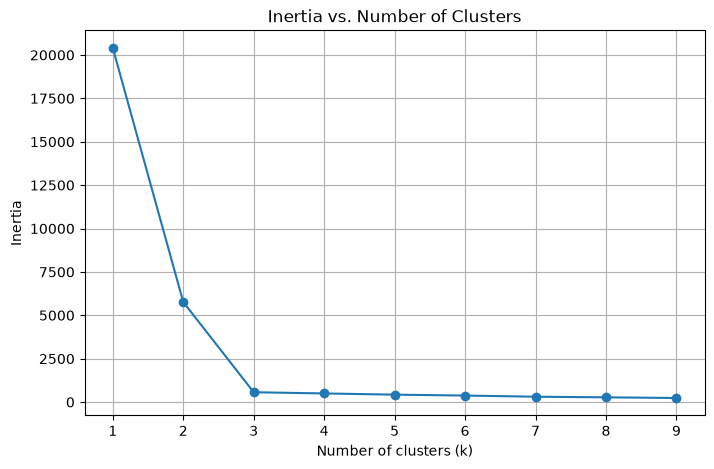

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 10),
    inertias,
    marker="o"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Inertia vs. Number of Clusters")
plt.xticks(range(1, 10))
plt.grid(True)
plt.show()

Task 8.1
- Inertia generally decreases as the number of clusters, k, increases.
- With more clusters, observations can be assigned to more specific and closer centroids. Therefore, the distances between observations and their assigned centroids generally become smaller, reducing the total inertia.
- The elbow is approximately at k = 3. The inertia decreases dramatically up to three clusters, while increasing k beyond 3 produces much smaller improvements.
- Because inertia generally continues to decrease as k increases. Selecting a very large k could produce very compact clusters but may unnecessarily divide the data into too many groups, making the clustering less useful or meaningful.
- Because inertia generally continues to decrease as k increases. Selecting a very large k could produce very compact clusters but may unnecessarily divide the data into too many groups, making the clustering less useful or meaningful.

In [20]:
iris_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

iris_kmeans.fit(X)

iris_clusters = iris_kmeans.labels_

print("Cluster centers:")
print(iris_kmeans.cluster_centers_)

print("\nInertia:")
print(iris_kmeans.inertia_)

Cluster centers:
[[5.9016129  2.7483871  4.39354839 1.43387097]
 [5.006      3.428      1.462      0.246     ]
 [6.85       3.07368421 5.74210526 2.07105263]]

Inertia:
78.851441426146


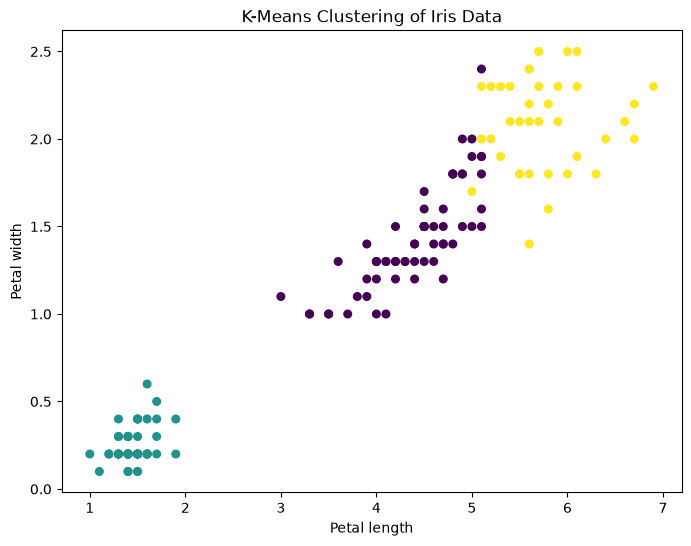

In [21]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 2],
    X[:, 3],
    c=iris_clusters,
    s=30
)

plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.title("K-Means Clustering of Iris Data")
plt.show()

Task 9.1
- Yes. The observations appear to form three main groups. One group is clearly separated at lower petal length and petal width values, while the other two groups are closer together and show some overlap.
- Petal length and petal width appear to provide useful separation between the clusters.
- No. The clusters are not perfectly separated. The purple and yellow clusters have some overlap, particularly around petal lengths of approximately 5.0–5.5 and petal widths around 1.5–2.0.
- Some observations may be difficult to assign because their feature values are similar to observations in more than one cluster. When points are close together in the feature space, their distances to different centroids may also be relatively similar, making the cluster assignment less obvious.

In [22]:
print("Original species:")
print(iris.target_names)

print("\nFirst 20 known labels:")
print(y[:20])

print("\nFirst 20 cluster assignments:")
print(iris_clusters[:20])

Original species:
['setosa' 'versicolor' 'virginica']

First 20 known labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

First 20 cluster assignments:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


Task 9.2
- The discovered clusters correspond reasonably well to the known Iris species. The setosa observations form a clearly separated group, while the other two groups have some overlap. Therefore, K-Means is able to discover much of the underlying structure of the Iris dataset without using the species labels.
- ecause K-Means assigns cluster numbers arbitrarily. Cluster 0 does not necessarily represent species 0, cluster 1 does not necessarily represent species 1, and so on. The numbers are simply identifiers generated by the clustering algorithm.
- Clustering is an unsupervised learning task where the algorithm discovers groups in the data without being given the correct class labels. Classification is supervised learning, where the model learns from known labels and predicts the class of new observations.